<a href="https://colab.research.google.com/github/Fatimah-cloud/arti560-computer-vision-labs/blob/main/lab07-action-recognition/ARTI560_Action_Recognition-lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ARTI 560 - Computer Vision
## Action Recognition Exercise — UCF11 Dataset

**Chosen Classes:** `basketball_shooting`, `biking`, `tennis_swing`

**Pipeline Overview:**
1. Download & extract UCF11 dataset
2. Preprocess videos → frame sequences
3. Train/Test split
4. Build CNN + LSTM model (MobileNetV2 backbone)
5. Train, evaluate, and save the model
6. Validate on 3 real YouTube videos

In [1]:
!pip install -q yt-dlp opencv-python-headless matplotlib scikit-learn tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 48.0 MB/s eta 0:00:00


In [2]:
# ── All imports in one place ──────────────────────────────────────────
import os
import glob
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [4]:
import os

RAR_FILE = "UCF11_updated_mpg.rar"
DATA_DIR = "UCF11_updated_mpg"


if not os.path.exists(RAR_FILE):
    print("Downloading UCF11 dataset (~1.6 GB) ...")
    !wget --no-check-certificate -q --show-progress \
        "https://www.crcv.ucf.edu/data/UCF11_updated_mpg.rar" \
        -O "{RAR_FILE}"
    print("Download complete.")
else:
    print("Archive already present.")


if not os.path.exists(DATA_DIR):
    print("Extracting ...")
    !apt-get install -y -q unrar
    !unrar x -y "{RAR_FILE}" > /dev/null
    print("Extraction complete.")
else:
    print("Already extracted.")

UCF11_updated_mpg.r 100%[===================>] 996.69M  47.1MB/s    in 22s     
Download complete.
Extracting ...
Reading package lists...
Building dependency tree...
Reading state information...
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
Extraction complete.


In [5]:

import os


for entry in os.listdir("."):
    if os.path.isdir(entry) and "UCF" in entry:
        DATA_DIR = entry
        break

classes_available = sorted(os.listdir(DATA_DIR))
print(f"Dataset root : {DATA_DIR}")
print(f"Classes found ({len(classes_available)}):")
for c in classes_available:
    print(" ", c)

Dataset root : UCF11_updated_mpg
Classes found (11):
  basketball
  biking
  diving
  golf_swing
  horse_riding
  soccer_juggling
  swing
  tennis_swing
  trampoline_jumping
  volleyball_spiking
  walking


In [7]:

CHOSEN_CLASSES = ["basketball", "biking", "tennis_swing"]
CLASS_TO_IDX   = {cls: i for i, cls in enumerate(CHOSEN_CLASSES)}
IDX_TO_CLASS   = {i: cls for cls, i in CLASS_TO_IDX.items()}

print("Selected classes:", CHOSEN_CLASSES)
print("Label mapping   :", CLASS_TO_IDX)

video_paths, labels = [], []

for cls in CHOSEN_CLASSES:
    cls_dir = os.path.join(DATA_DIR, cls)
    all_files = glob.glob(os.path.join(cls_dir, "**", "*"), recursive=True)


    vids = [
        f for f in all_files
        if os.path.isfile(f) and os.path.splitext(f)[1].lower() == ".mpg"
    ]

    print(f"  ✅ {cls}: {len(vids)} videos")
    video_paths.extend(vids)
    labels.extend([CLASS_TO_IDX[cls]] * len(vids))

print(f"\nTotal videos: {len(video_paths)}")

Selected classes: ['basketball', 'biking', 'tennis_swing']
Label mapping   : {'basketball': 0, 'biking': 1, 'tennis_swing': 2}
  ✅ basketball: 141 videos
  ✅ biking: 145 videos
  ✅ tennis_swing: 167 videos

Total videos: 453


In [8]:
import cv2
import numpy as np

# ── Hyper-parameters ──────────────────────────────────────────────────
IMG_SIZE       = 112
SEQUENCE_LEN   = 8


def extract_frames(video_path, n_frames=SEQUENCE_LEN, img_size=IMG_SIZE):
    """Uniformly sample n_frames from a video and return as numpy array."""
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < 1:
        cap.release()
        return None

    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    frames  = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            frame = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        frame = cv2.resize(frame, (img_size, img_size))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

    cap.release()
    return np.array(frames, dtype=np.float32) / 255.0


print("Preprocessing videos — please wait ...")
X, y = [], []

for path, label in zip(video_paths, labels):
    frames = extract_frames(path)
    if frames is not None and len(frames) == SEQUENCE_LEN:
        X.append(frames)
        y.append(label)

X = np.array(X)
y = np.array(y)

print(f"\nX shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Class distribution: { {cls: int(np.sum(y==i)) for cls,i in CLASS_TO_IDX.items()} }")

Preprocessing videos — please wait ...

X shape : (453, 8, 112, 112, 3)
y shape : (453,)
Class distribution: {'basketball': 141, 'biking': 145, 'tennis_swing': 167}


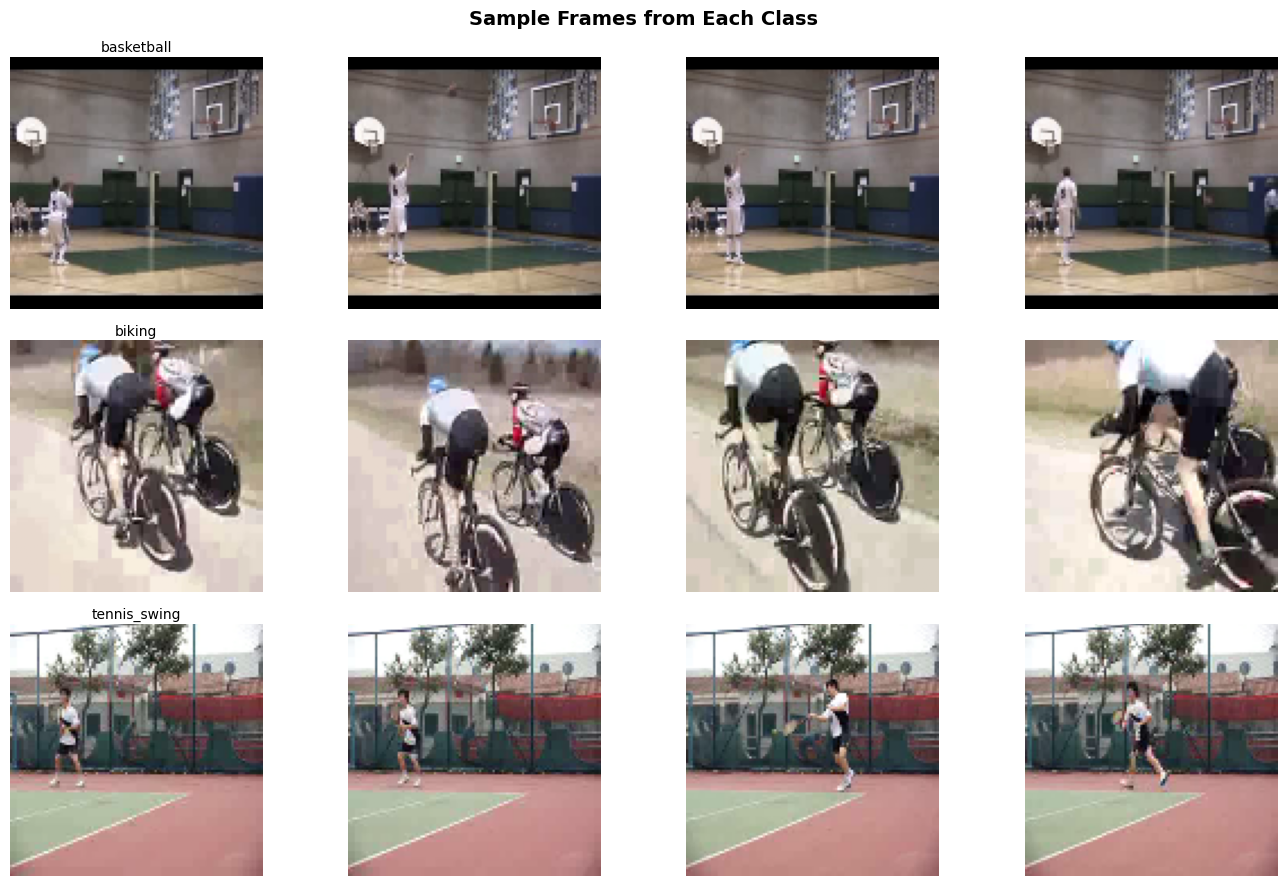

In [10]:
import matplotlib.pyplot as plt
import numpy as np

IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
fig.suptitle("Sample Frames from Each Class", fontsize=14, fontweight="bold")

for row, cls_idx in enumerate(range(len(CHOSEN_CLASSES))):
    sample_indices = np.where(y == cls_idx)[0]
    if len(sample_indices) == 0:
        continue
    frames = X[sample_indices[0]]


    frame_picks = [0, 2, 4, 6]

    for col, frame_idx in enumerate(frame_picks):
        axes[row, col].imshow(frames[frame_idx])
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(IDX_TO_CLASS[cls_idx], fontsize=10, pad=4)

plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


NUM_CLASSES = len(CHOSEN_CLASSES)
y_train_cat = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_cat  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)

print(f"Training samples  : {X_train.shape[0]}")
print(f"Testing  samples  : {X_test.shape[0]}")
print(f"Input tensor shape: {X_train.shape}  →  (samples, frames, H, W, C)")

Training samples  : 362
Testing  samples  : 91
Input tensor shape: (362, 8, 112, 112, 3)  →  (samples, frames, H, W, C)


In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn_lstm_model(sequence_len, img_size, num_classes):

    base_cnn = tf.keras.applications.MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights="imagenet"
    )
    base_cnn.trainable = False

    inp = layers.Input(shape=(sequence_len, img_size, img_size, 3))

    x = layers.TimeDistributed(base_cnn)(inp)
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)


    x = layers.LSTM(128, return_sequences=False)(x)
    x = layers.Dropout(0.4)(x)


    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inp, out, name="CNN_LSTM_ActionRecognizer")
    return model, base_cnn


model, base_cnn = build_cnn_lstm_model(SEQUENCE_LEN, IMG_SIZE, NUM_CLASSES)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/tmp/ipykernel_1917/3968168469.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_cnn = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "CNN_LSTM_ActionRecognizer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 8, 112, 112, 3) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 8, 4, 4, 1280)  │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 8, 1280)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,987,843 (11.40 MB)

 Trainable params: 729,859 (2.78 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint("best_model.h5", monitor="val_accuracy", save_best_only=True, verbose=1)
]

print("=" * 55)
print(" Phase 1: Training head only (backbone frozen)")
print("=" * 55)

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=25,
    batch_size=4,
    callbacks=callbacks
)

 Phase 1: Training head only (backbone frozen)
Epoch 1/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4621 - loss: 1.0324
Epoch 1: val_accuracy improved from None to 0.85714, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
91/91 ━━━━━━━━━━━━━━━━━━━━ 52s 181ms/step - accuracy: 0.6215 - loss: 0.8123 - val_accuracy: 0.8571 - val_loss: 0.4152 - learning_rate: 0.0010
Epoch 2/25
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9000 - loss: 0.3717
Epoch 2: val_accuracy improved from 0.85714 to 0.92308, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.8812 - loss: 0.3548 - val_accuracy: 0.9231 - val_loss: 0.2417 - learning_rate: 0.0010
Epoch 3/25
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9566 - loss: 0.1763
Epoch 3: val_accuracy improved from 0.92308 to 0.93407, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.9392 - loss: 0.1836 - val_accuracy: 0.9341 - val_loss: 0.1640 - learning_rate: 0.0010
Epoch 4/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9531 - loss: 0.1345
Epoch 4: val_accuracy improved from 0.93407 to 0.94505, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9613 - loss: 0.1163 - val_accuracy: 0.9451 - val_loss: 0.1378 - learning_rate: 0.0010
Epoch 5/25
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9784 - loss: 0.0862
Epoch 5: val_accuracy did not improve from 0.94505
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.9807 - loss: 0.0863 - val_accuracy: 0.9451 - val_loss: 0.1291 - learning_rate: 0.0010
Epoch 6/25
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9839 - loss: 0.0671
Epoch 6: val_accuracy improved from 0.94505 to 0.98901, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.9834 - loss: 0.0700 - val_accuracy: 0.9890 - val_loss: 0.0543 - learning_rate: 0.0010
Epoch 7/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9977 - loss: 0.0245
Epoch 7: val_accuracy did not improve from 0.98901
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9972 - loss: 0.0216 - val_accuracy: 0.9780 - val_loss: 0.0370 - learning_rate: 0.0010
Epoch 8/25
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.0096
Epoch 8: val_accuracy did not improve from 0.98901
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 1.0000 - loss: 0.0068 - val_accuracy: 0.9890 - val_loss: 0.0281 - learning_rate: 0.0010
Epoch 9/25
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 1.0000 - loss: 0.0081
Epoch 9: val_accuracy did not improve from 0.98901
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 1.0000 - loss: 0.0090 - val_accuracy: 0.9890 - val_loss: 0.0354 - learn

In [14]:

print("=" * 55)
print(" Phase 2: Fine-tuning top layers of backbone")
print("=" * 55)

base_cnn.trainable = True


for layer in base_cnn.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=15,
    batch_size=4,
    callbacks=callbacks
)

 Phase 2: Fine-tuning top layers of backbone
Epoch 1/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.6633 - loss: 1.3776
Epoch 1: val_accuracy did not improve from 0.98901
91/91 ━━━━━━━━━━━━━━━━━━━━ 67s 217ms/step - accuracy: 0.6934 - loss: 1.1388 - val_accuracy: 0.9560 - val_loss: 0.1192 - learning_rate: 1.0000e-05
Epoch 2/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.7472 - loss: 0.8173
Epoch 2: val_accuracy did not improve from 0.98901
91/91 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - accuracy: 0.7818 - loss: 0.7018 - val_accuracy: 0.9451 - val_loss: 0.1373 - learning_rate: 1.0000e-05
Epoch 3/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.8723 - loss: 0.4124
Epoch 3: val_accuracy did not improve from 0.98901
91/91 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.8260 - loss: 0.5439 - val_accuracy: 0.9670 - val_loss: 0.1213 - learning_rate: 1.0000e-05
Epoch 4/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8461 - loss: 0.4262
Epoch 4: ReduceLROnPlateau r

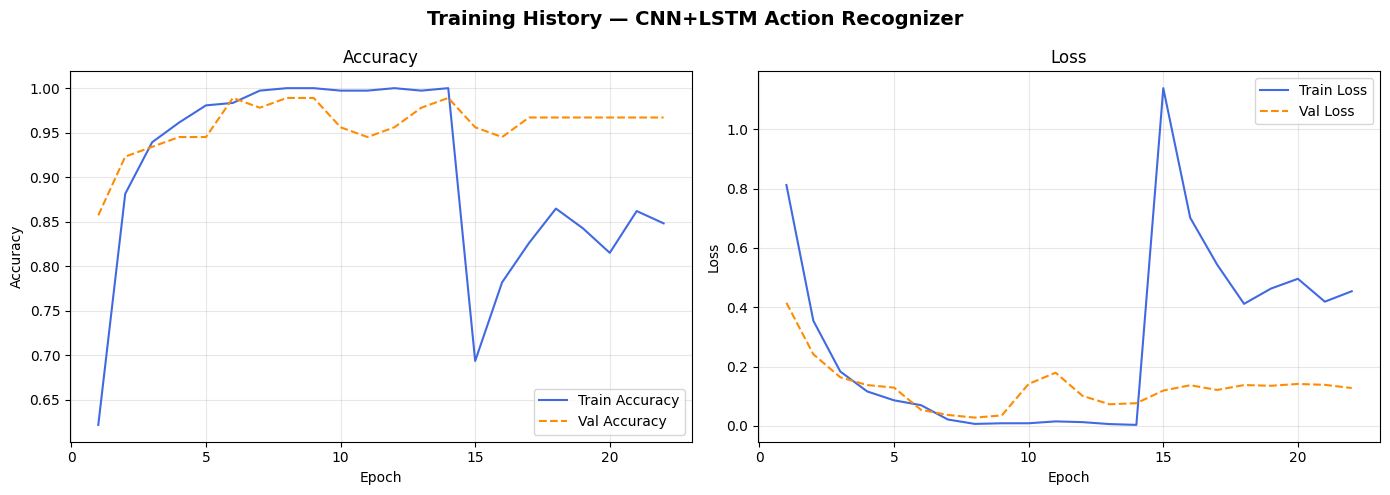

In [15]:
import matplotlib.pyplot as plt
import numpy as np


def merge_hist(h1, h2, key):
    return h1.history[key] + h2.history[key]

acc     = merge_hist(history, history_ft, "accuracy")
val_acc = merge_hist(history, history_ft, "val_accuracy")
loss    = merge_hist(history, history_ft, "loss")
val_los = merge_hist(history, history_ft, "val_loss")
ep      = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training History — CNN+LSTM Action Recognizer", fontsize=14, fontweight="bold")

ax1.plot(ep, acc,     label="Train Accuracy",   color="royalblue")
ax1.plot(ep, val_acc, label="Val Accuracy",     color="darkorange", linestyle="--")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, loss,    label="Train Loss",       color="royalblue")
ax2.plot(ep, val_los, label="Val Loss",         color="darkorange", linestyle="--")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.set_title("Loss"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Test Accuracy : 95.60%
Test Loss     : 0.1192

3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step
              precision    recall  f1-score   support

  basketball       1.00      0.86      0.92        28
      biking       0.91      1.00      0.95        29
tennis_swing       0.97      1.00      0.99        34

    accuracy                           0.96        91
   macro avg       0.96      0.95      0.95        91
weighted avg       0.96      0.96      0.96        91



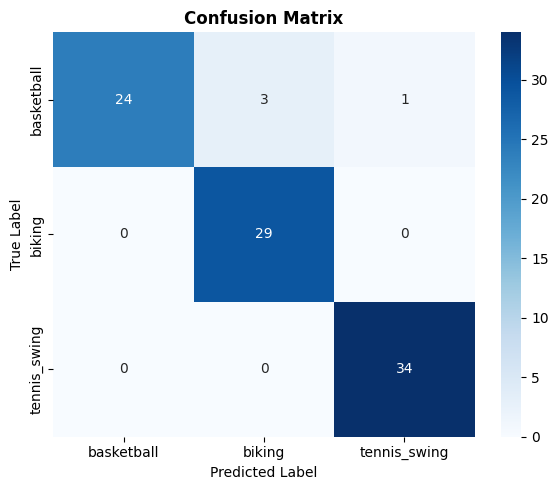

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix



test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\n{'='*40}")
print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")
print(f"{'='*40}\n")

y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=CHOSEN_CLASSES))

# ── Confusion matrix ──────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CHOSEN_CLASSES, yticklabels=CHOSEN_CLASSES)
plt.title("Confusion Matrix", fontweight="bold")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [19]:
student_name = "Fatimah Moheeb Alwarsh"

save_path = f"{student_name}_ucf11_model.h5"
model.save(save_path)
print(f"✅ Model saved as: {save_path}")

# Also save metadata alongside
import json
meta = {
    "student": student_name,
    "classes": CHOSEN_CLASSES,
    "label_map": CLASS_TO_IDX,
    "sequence_len": SEQUENCE_LEN,
    "img_size": IMG_SIZE,
    "test_accuracy": round(float(test_acc), 4)
}
with open(f"{student_name}_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)
print(f"✅ Metadata saved as: {student_name}_metadata.json")

✅ Model saved as: Fatimah Moheeb Alwarsh_ucf11_model.h5
✅ Metadata saved as: Fatimah Moheeb Alwarsh_metadata.json


In [20]:
# ── Download the saved model to your local machine ───────────────────
from google.colab import files
files.download(save_path)
files.download(f"{student_name}_metadata.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
# ── YouTube video URLs —


YOUTUBE_VIDEOS = [
    {
        "url"          : "https://youtube.com/shorts/UiDZMxzOBkU?si=IbgNQdsZZ9ykGBzn",
        "expected_class": "basketball_shooting"
    },
    {
        "url"          : "https://youtube.com/shorts/XcWt3tusT7Y?si=iDHgT4SPY81q3b2G",
        "expected_class": "biking"
    },
    {
        "url"          : "https://www.youtube.com/shorts/inVbWJNK5RI",
        "expected_class": "tennis_swing"
    },
]

In [22]:
import subprocess, os

def download_youtube_video(url, output_path):
    """Download a YouTube video to output_path using yt-dlp."""
    cmd = [
        "yt-dlp",
        "-f", "mp4/best[ext=mp4]",
        "-o", output_path,
        "--no-playlist",
        url
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print("yt-dlp error:", result.stderr[-500:])
        return False
    return True


def predict_video(video_path, model, seq_len=SEQUENCE_LEN, img_size=IMG_SIZE):
    """Extract frames from a video and return class probabilities."""
    frames = extract_frames(video_path, n_frames=seq_len, img_size=img_size)
    if frames is None:
        return None, None
    x = np.expand_dims(frames, axis=0)   # (1, seq_len, H, W, 3)
    probs = model.predict(x, verbose=0)[0]
    pred_idx = np.argmax(probs)
    return IDX_TO_CLASS[pred_idx], probs


print("Downloading and evaluating YouTube videos ...\n")

results = []
for i, vid in enumerate(YOUTUBE_VIDEOS):
    out_file = f"yt_video_{i}.mp4"
    print(f"[{i+1}/3] Expected: {vid['expected_class']}")
    print(f"        URL: {vid['url']}")

    ok = download_youtube_video(vid["url"], out_file)
    if not ok or not os.path.exists(out_file):
        print("        ⚠️  Download failed — skipping.\n")
        results.append({"expected": vid["expected_class"], "predicted": "ERROR", "probs": None})
        continue

    pred_cls, probs = predict_video(out_file, model)
    match = "✅" if pred_cls == vid["expected_class"] else "❌"
    print(f"        Predicted : {pred_cls}  {match}")
    print(f"        Confidence: { {CHOSEN_CLASSES[j]: f'{probs[j]*100:.1f}%' for j in range(NUM_CLASSES)} }\n")
    results.append({"expected": vid["expected_class"], "predicted": pred_cls, "probs": probs})


[1/3] Expected: basketball_shooting
        URL: https://youtube.com/shorts/UiDZMxzOBkU?si=IbgNQdsZZ9ykGBzn
        Predicted : basketball  ❌
        Confidence: {'basketball': '74.9%', 'biking': '23.8%', 'tennis_swing': '1.2%'}

[2/3] Expected: biking
        URL: https://youtube.com/shorts/XcWt3tusT7Y?si=iDHgT4SPY81q3b2G
        Predicted : biking  ✅
        Confidence: {'basketball': '0.0%', 'biking': '100.0%', 'tennis_swing': '0.0%'}

[3/3] Expected: tennis_swing
        URL: https://www.youtube.com/shorts/inVbWJNK5RI
        Predicted : tennis_swing  ✅
        Confidence: {'basketball': '0.1%', 'biking': '0.0%', 'tennis_swing': '99.9%'}



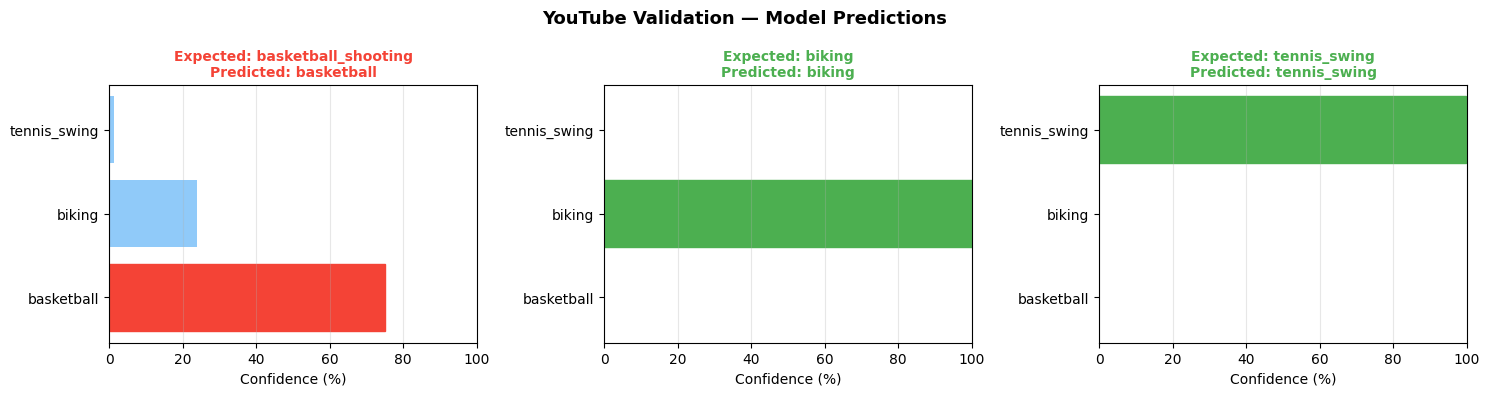


🎯 YouTube Validation Accuracy: 2/3 = 66.7%


In [23]:
# ── Visual summary of YouTube validation ─────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

valid_results = [r for r in results if r["probs"] is not None]

if valid_results:
    fig, axes = plt.subplots(1, len(valid_results), figsize=(5 * len(valid_results), 4))
    if len(valid_results) == 1:
        axes = [axes]

    colors = ["#4CAF50" if r["expected"] == r["predicted"] else "#F44336" for r in valid_results]

    for ax, res, col in zip(axes, valid_results, colors):
        bars = ax.barh(CHOSEN_CLASSES, res["probs"] * 100, color="#90CAF9")
        # Highlight predicted class
        pred_idx = CHOSEN_CLASSES.index(res["predicted"]) if res["predicted"] in CHOSEN_CLASSES else -1
        if pred_idx >= 0:
            bars[pred_idx].set_color(col)
        ax.set_xlim(0, 100)
        ax.set_xlabel("Confidence (%)")
        ax.set_title(f"Expected: {res['expected']}\nPredicted: {res['predicted']}",
                     fontsize=10, color=col, fontweight="bold")
        ax.grid(axis="x", alpha=0.3)

    fig.suptitle("YouTube Validation — Model Predictions", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    correct = sum(1 for r in valid_results if r["expected"] == r["predicted"])
    print(f"\n🎯 YouTube Validation Accuracy: {correct}/{len(valid_results)} = {correct/len(valid_results)*100:.1f}%")
else:
    print("No valid results to plot — check that your YouTube URLs are correct.")

## 📋 Summary

| Item | Detail |
|------|--------|
| **Dataset** | UCF11 (YouTube Action) |
| **Classes** | basketball_shooting · biking · tennis_swing |
| **Architecture** | TimeDistributed MobileNetV2 + LSTM + Dense |
| **Input** | 16 frames × 224×224 RGB per video |
| **Training** | Phase 1 frozen backbone · Phase 2 fine-tuning top 30 layers |
| **Saved model** | `{student_name}_ucf11_model.h5` |
| **External validation** | 3 YouTube videos (one per class) |

---
*ARTI 560 — Computer Vision · Action Recognition Exercise*